# Exploracion al espacio critico
Obtenido a partir de varias runs aleatorias utilizando el codigo de c++ y el cluster Kosmos

Número de archivos encontrados: 8
Procesando archivo: 0207c_phys.csv
Procesando archivo: 0207_phys.csv
Procesando archivo: 0320.csv
Procesando archivo: 0320b.csv
Procesando archivo: 1.csv
Procesando archivo: 2.csv
Procesando archivo: 3.csv
Procesando archivo: physf.csv

Dataset filtrado: 64772 registros cumplen la condición BR > 0.8.
Dataset filtrado guardado en: filtered_BR_above_0.8.csv

Estadísticas del Branching Ratio en el subset filtrado:
count    64772.000000
mean         0.858286
std          0.048781
min          0.800412
25%          0.809559
50%          0.845036
75%          0.912259
max          0.913444
Name: branching_ratio_h2_gaga, dtype: float64


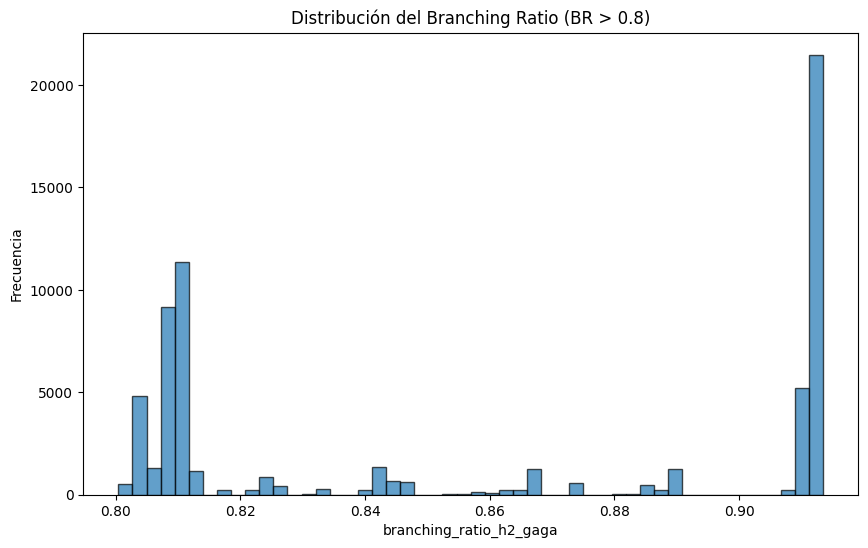

In [1]:
# %% Celda: Filtrado de CSV para casos con Branching Ratio > 0.8

import glob
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ------------------ Variables Globales Modificables ------------------
FILE_PATTERN = "outphys/*.csv"   # Patrón para localizar los archivos CSV
CHUNKSIZE = 10000                        # Número de filas a leer por chunk
TARGET_COL = "branching_ratio_h2_gaga"     # Nombre de la columna del Branching Ratio
BR_THRESHOLD = 0.8                       # Umbral del Branching Ratio (> 0.8)
OUTPUT_FILENAME = "filtered_BR_above_0.8.csv"  # Archivo de salida

# ------------------ Inicialización ------------------
filtered_records = []  # Lista para almacenar los datos filtrados
files = glob.glob(FILE_PATTERN)
print(f"Número de archivos encontrados: {len(files)}")

# ------------------ Procesamiento y Filtrado ------------------
for file in files:
    print(f"Procesando archivo: {os.path.basename(file)}")
    try:
        for chunk in pd.read_csv(file, chunksize=CHUNKSIZE):
            # Verificar que el chunk tenga la columna TARGET_COL
            if TARGET_COL not in chunk.columns:
                print(f"  [!] El archivo {file} no contiene la columna {TARGET_COL}. Se omite este chunk.")
                continue
            
            # Convertir la columna a numérico y eliminar filas con NaN en TARGET_COL
            chunk[TARGET_COL] = pd.to_numeric(chunk[TARGET_COL], errors='coerce')
            chunk = chunk.dropna(subset=[TARGET_COL])
            
            # Filtrar el chunk para casos con BR > 0.8
            filtered_chunk = chunk[chunk[TARGET_COL] > BR_THRESHOLD]
            
            if not filtered_chunk.empty:
                filtered_records.append(filtered_chunk)
    except Exception as e:
        print(f"Error al procesar {file}: {e}")

# ------------------ Combinación y Guardado ------------------
if filtered_records:
    df_filtered = pd.concat(filtered_records, ignore_index=True)
    print(f"\nDataset filtrado: {df_filtered.shape[0]} registros cumplen la condición BR > {BR_THRESHOLD}.")
    
    # Guardar el dataset filtrado en un CSV
    df_filtered.to_csv(OUTPUT_FILENAME, index=False)
    print(f"Dataset filtrado guardado en: {OUTPUT_FILENAME}")
    
    # ------------------ Análisis Estadístico del Branching Ratio ------------------
    print("\nEstadísticas del Branching Ratio en el subset filtrado:")
    print(df_filtered[TARGET_COL].describe())
    
    # Histograma del Branching Ratio
    plt.figure(figsize=(10, 6))
    plt.hist(df_filtered[TARGET_COL], bins=50, edgecolor='k', alpha=0.7)
    plt.xlabel(TARGET_COL)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución del Branching Ratio (BR > {BR_THRESHOLD})")
    plt.show()
else:
    print("No se encontraron registros con Branching Ratio > 0.8.")


In [2]:
df80 = df_filtered
df80.describe()

,m_phi,mA,alpha,beta,lambda6,lambda7,m12,sin_ba,tan_beta,positivity_ok,unitarity_ok,perturbativity_ok,width_h2_bb,width_h2_tautau,width_h2_WW,width_h2_ZZ,width_h2_gaga,total_width_h2,branching_ratio_h2_gaga
count,64772.000000,64772.000000,64772.000000,64772.000000,64772.000000,64772.000000,64772.000000,64772.000000,64772.000000,64772.000000,64772.0,64772.0,64772.0,64772.0,6.477200e+04,6.477200e+04,6.477200e+04,6.477200e+04,64772.000000
mean,137.931141,291.660183,0.031352,1.165599,-9.978793,-0.817334,-7.932720,0.745195,3903.985550,0.284691,0.0,0.0,0.0,0.0,1.738344e-05,2.087472e-06,6.658952e+09,7.950251e+09,0.858286
std,11.818588,109.694229,0.031676,1.042569,25.697952,28.722903,16.867029,0.664810,4618.021444,0.451271,0.0,0.0,0.0,0.0,3.197289e-05,3.826355e-06,4.381835e+10,5.329421e+10,0.048781
min,125.000000,130.000000,-0.000510,-1.571896,-60.000000,-50.000000,-50.000000,-1.000000,49.733578,0.000000,0.0,0.0,0.0,0.0,2.346000e-12,3.200000e-13,8.278648e-02,9.064789e-02,0.800412
25%,125.000000,200.452100,0.000100,1.550692,-29.858470,-17.768665,-30.000000,0.995934,66.200705,0.000000,0.0,0.0,0.0,0.0,4.990870e-10,5.976200e-11,2.561069e+01,3.005139e+01,0.809559
50%,139.796280,300.000000,0.020100,1.560692,-9.716940,0.100000,-9.800000,0.998740,195.906540,0.000000,0.0,0.0,0.0,0.0,2.570647e-06,3.211162e-07,2.629007e+03,2.880426e+03,0.845036
75%,150.314000,375.000000,0.060100,1.570692,10.424590,10.000000,10.400000,0.999884,9575.748083,1.000000,0.0,0.0,0.0,0.0,1.479450e-05,1.771525e-06,4.832251e+06,5.873844e+06,0.912259
max,151.570000,500.000000,0.090100,1.570692,40.707650,50.000000,29.400000,1.000000,9999.679467,1.000000,0.0,0.0,0.0,0.0,1.444523e-04,1.729702e-05,5.362067e+11,6.679958e+11,0.913444


Top 3 combinaciones (usando sort_values) de parámetros con mayor BR:
       m_phi     mA   alpha      beta   lambda6  lambda7   m12
46709  125.0  450.0  0.0901  1.550692  30.56612     10.0  10.4
46209  125.0  450.0  0.0901  1.550692  30.56612     10.0  -9.8
45704  125.0  450.0  0.0901  1.550692  30.56612     10.0 -30.0

Top 3 combinaciones (usando where) de parámetros con mayor BR:
       m_phi     mA   alpha      beta   lambda6  lambda7   m12
45704  125.0  450.0  0.0901  1.550692  30.56612     10.0 -30.0
46209  125.0  450.0  0.0901  1.550692  30.56612     10.0  -9.8
46709  125.0  450.0  0.0901  1.550692  30.56612     10.0  10.4

Número de registros con BR > 0.9: 0


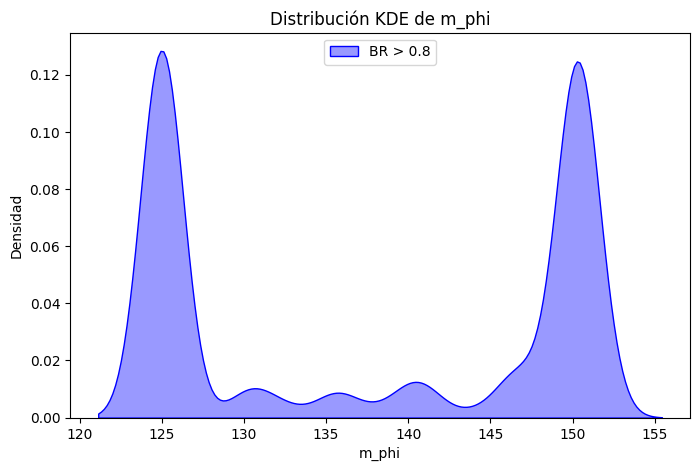

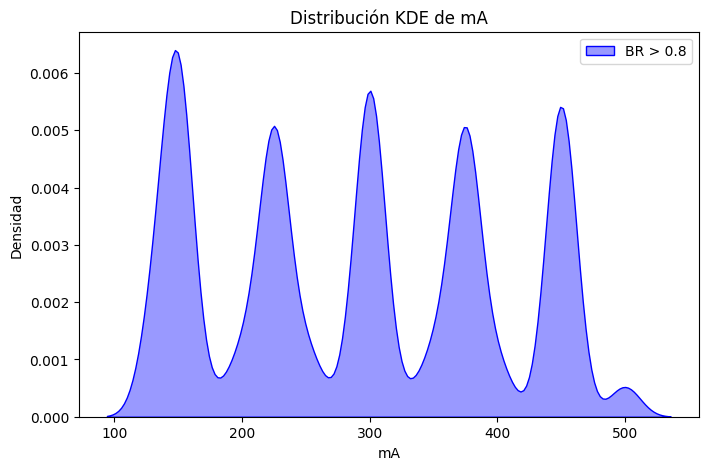

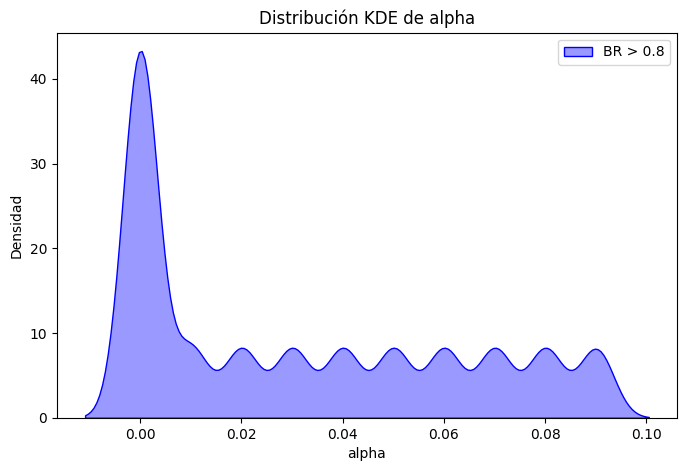

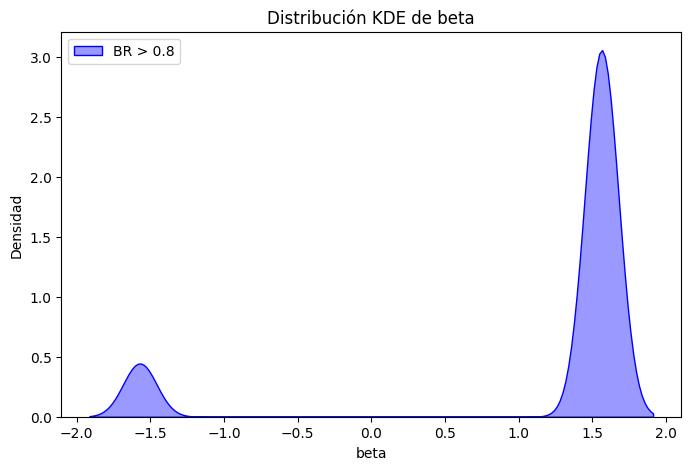

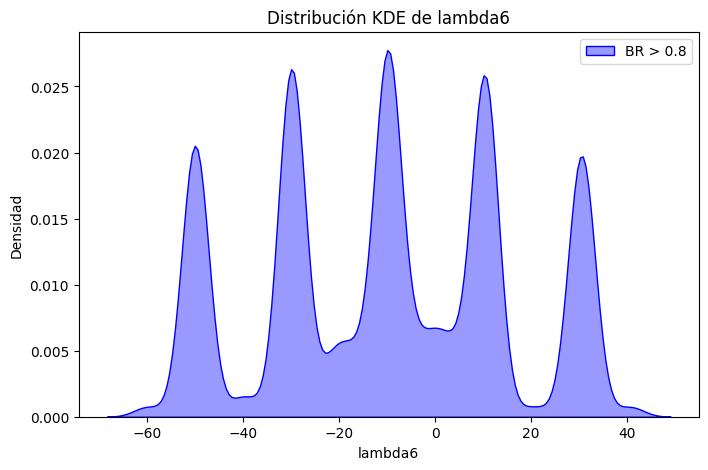

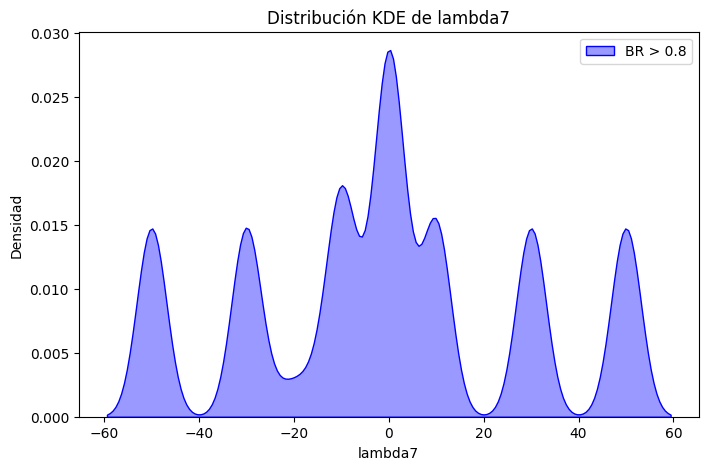

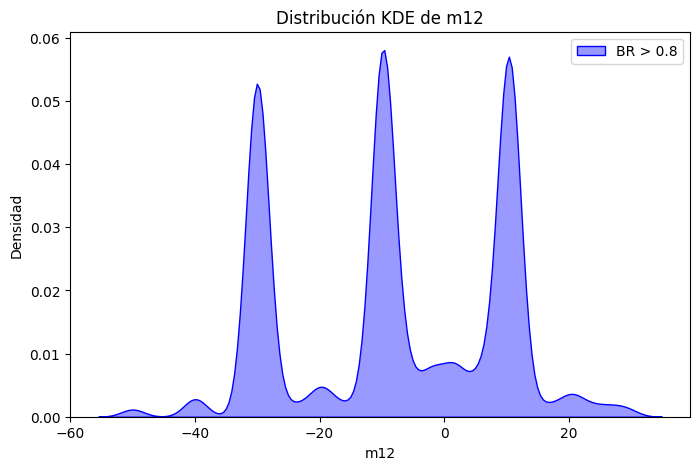

In [3]:
# %% Celda: Extracción del Top 3 y gráficos KDE comparativos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Variables globales (ajustables) ---
TARGET_COL = "branching_ratio_h2_gaga"
PARAM_COLS = ['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12']

# --- Supuestos ---
# Se asume que 'df80' es un DataFrame que contiene los registros con BR > 0.8.
# Por ejemplo, se obtuvo con:
# df80 = df_filtered  (donde BR > 0.8 ya fue aplicado en el filtrado previo)

# --- Paso 1: Obtener las 3 combinaciones con los BR mayores ---
# Opción 1: Utilizando sort_values y head
df80_top3 = df80.sort_values(by=TARGET_COL, ascending=False).head(3)

# Opción 2: Utilizando where (filtramos para aquellos registros cuyo BR esté en el top 3)
# En este caso usamos nlargest para obtener el mínimo de los top 3, y luego filtramos.
top3_threshold = df80[TARGET_COL].nlargest(3).min()
df80_top3_where = df80.where(df80[TARGET_COL] >= top3_threshold).dropna(subset=[TARGET_COL])
# Ambas opciones deben producir resultados similares

print("Top 3 combinaciones (usando sort_values) de parámetros con mayor BR:")
print(df80_top3[PARAM_COLS])
print("\nTop 3 combinaciones (usando where) de parámetros con mayor BR:")
print(df80_top3_where[PARAM_COLS])

# --- Paso 2: Filtrar el subconjunto para casos con BR > 0.9 ---
df90 = df80[df80[TARGET_COL] < 0.5]
print(f"\nNúmero de registros con BR > 0.9: {df90.shape[0]}")

# --- Paso 3: Gráficos KDE comparativos para cada parámetro ---
# Para cada variable en PARAM_COLS se dibujará un gráfico KDE:
for col in PARAM_COLS:
    plt.figure(figsize=(8, 5))
    # KDE para el conjunto completo (BR > 0.8)
    sns.kdeplot(df80[col], label='BR > 0.8', color='blue', fill=True, alpha=0.4)
    # KDE para el subconjunto (BR > 0.9)
    sns.kdeplot(df90[col], label='BR > 0.9', color='red', fill=True, alpha=0.4)
    plt.title(f"Distribución KDE de {col}")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend()
    plt.show()


# Estudio del Espacio Crítico

Se ha definido un nuevo rango para la creación de un conjunto de *runs* denominado **eta**. A continuación se presentan los rangos asignados a algunos de los parámetros clave, así como los parámetros pendientes de explorar:

## Rango de Parámetros para Runs "eta"

- **$m_\phi$:** (124, 200)
- **$\beta$:** $\pm \frac{\pi}{2}$
    - se indicara una run por `p` cuando sea cercano a la parte positiva de $\beta$
- **$\alpha$:** ($-10^{-3}$, $5\times10^{-3}$)

## Parámetros por Seguir Explorando

- $m_A$
- $\lambda_6$
- $\lambda_7$
- $m_{12}$

## Runs generadas:


Número de archivos encontrados: 8
Procesando archivo: 0207c_phys.csv
Procesando archivo: 0207_phys.csv
Procesando archivo: 0320.csv
Procesando archivo: 0320b.csv
Procesando archivo: 1.csv
Procesando archivo: 2.csv
Procesando archivo: 3.csv
Procesando archivo: physf.csv

Dataset filtrado: 133364 registros.
Dataset filtrado guardado en: filtered_dataset.csv

Estadísticas del Branching Ratio en el subespacio crítico:
count    133364.000000
mean          0.569209
std           0.376932
min           0.000000
25%           0.000000
50%           0.734841
75%           0.825357
max           0.913444
Name: branching_ratio_h2_gaga, dtype: float64


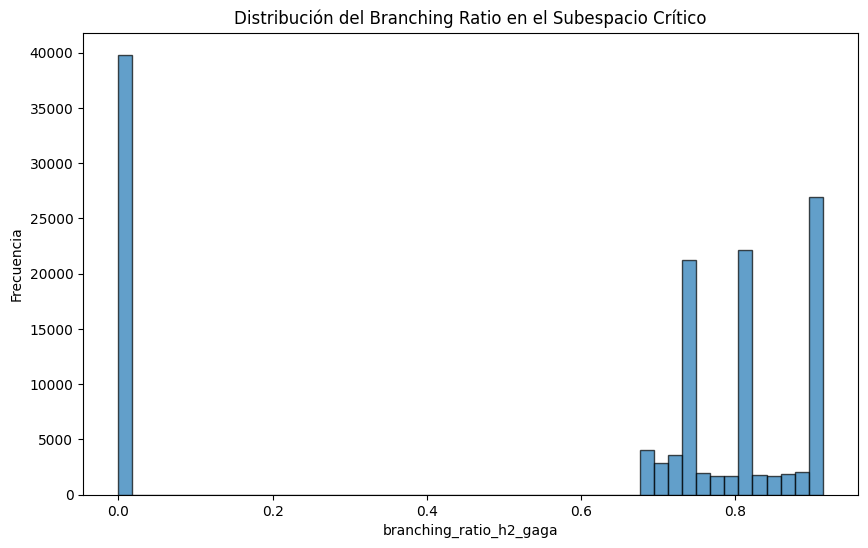

In [2]:
# Extracción y Análisis del Subespacio Crítico

import glob
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ------------------ Variables Globales Modificables ------------------
FILE_PATTERN = "outphys/*.csv"  # Ajusta la ruta según tus archivos
CHUNKSIZE = 10000                       # Número de filas a procesar por chunk

# Rango óptimo en escala original para m_phi y beta
optimal_m_phi_min = 124.0   # Valor mínimo óptimo para m_phi (ajústalo según tus datos)
optimal_m_phi_max = 200.0   # Valor máximo óptimo para m_phi
optimal_beta_min   = -2    # Valor mínimo óptimo para beta (ajústalo)
optimal_beta_max   = 2    # Valor máximo óptimo para beta

# Nombre de la columna para Branching Ratio
TARGET_COL = "branching_ratio_h2_gaga"

# Nombre del archivo de salida para el dataset filtrado
OUTPUT_FILENAME = "filtered_dataset.csv"

# ------------------ Inicialización ------------------
filtered_records = []  # Lista para almacenar los DataFrames filtrados
files = glob.glob(FILE_PATTERN)
print(f"Número de archivos encontrados: {len(files)}")

# ------------------ Procesamiento de Archivos ------------------
for file in files:
    print(f"Procesando archivo: {os.path.basename(file)}")
    try:
        for chunk in pd.read_csv(file, chunksize=CHUNKSIZE):
            # Verificar que el chunk tenga las columnas necesarias
            required_cols = ['m_phi', 'beta', 'mA', TARGET_COL]
            if not set(required_cols).issubset(chunk.columns):
                print(f"  [!] El archivo {file} no tiene todas las columnas requeridas: {required_cols}")
                continue
            
            # Convertir columnas a numérico (en caso de haber problemas de formato)
            for col in required_cols:
                chunk[col] = pd.to_numeric(chunk[col], errors='coerce')
            
            # Eliminar filas con NaN en las columnas clave
            chunk = chunk.dropna(subset=required_cols)
            
            # Aplicar condiciones:
            # 1. m_phi dentro del rango óptimo
            # 2. beta dentro del rango óptimo
            # 3. mA > m_phi
            mask = (chunk["m_phi"] >= optimal_m_phi_min) & (chunk["m_phi"] <= optimal_m_phi_max) & \
                   (chunk["beta"] >= optimal_beta_min) & (chunk["beta"] <= optimal_beta_max) & \
                   (chunk["mA"] > chunk["m_phi"])
            
            filtered_chunk = chunk[mask]
            if not filtered_chunk.empty:
                filtered_records.append(filtered_chunk)
    except Exception as e:
        print(f"Error al procesar {file}: {e}")

# ------------------ Combinación y Guardado ------------------
if filtered_records:
    df_filtered = pd.concat(filtered_records, ignore_index=True)
    print(f"\nDataset filtrado: {df_filtered.shape[0]} registros.")
    
    # Guardar el dataset filtrado en un CSV
    df_filtered.to_csv(OUTPUT_FILENAME, index=False)
    print(f"Dataset filtrado guardado en: {OUTPUT_FILENAME}")
else:
    print("No se encontró ningún registro que cumpla las condiciones.")

# ------------------ Análisis Estadístico del Branching Ratio ------------------
if not filtered_records:
    print("No hay datos para analizar el Branching Ratio.")
else:
    print("\nEstadísticas del Branching Ratio en el subespacio crítico:")
    print(df_filtered[TARGET_COL].describe())
    
    # Histograma del Branching Ratio
    plt.figure(figsize=(10, 6))
    plt.hist(df_filtered[TARGET_COL], bins=50, edgecolor='k', alpha=0.7)
    plt.xlabel(TARGET_COL)
    plt.ylabel("Frecuencia")
    plt.title("Distribución del Branching Ratio en el Subespacio Crítico")
    plt.show()


In [3]:
df_filtered.describe()

,m_phi,mA,alpha,beta,lambda6,lambda7,m12,sin_ba,tan_beta,positivity_ok,unitarity_ok,perturbativity_ok,width_h2_bb,width_h2_tautau,width_h2_WW,width_h2_ZZ,width_h2_gaga,total_width_h2,branching_ratio_h2_gaga
count,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.000000,133364.0,133364.0,1.333640e+05,1.333640e+05,9.354800e+04,9.354800e+04,133364.000000
mean,152.829070,315.773764,0.027735,0.987640,-8.509889,0.020125,-7.239865,0.629668,3098.848644,0.574443,0.298551,0.298551,0.0,0.0,2.530244e-04,9.838173e-06,3.196649e+09,3.864790e+09,0.569209
std,23.471308,94.988654,0.031409,1.217361,24.730446,26.807113,16.662186,0.775507,4885.558744,0.494429,0.457624,0.457624,0.0,0.0,8.462844e-04,3.091614e-05,2.003139e+10,2.347622e+10,0.376932
min,125.000000,130.000000,0.000100,-1.570896,-60.000000,-50.000000,-50.000000,-1.000000,-3333.368846,0.000000,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,8.278648e-02,9.064789e-02,0.000000
25%,125.000000,225.000000,0.000100,1.550692,-29.858470,-10.000000,-23.400000,0.995934,-101.052027,0.000000,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,3.572890e+01,4.444834e+01,0.000000
50%,150.314000,300.000000,0.010100,1.565692,-9.716940,0.100000,-9.800000,0.998740,98.963120,1.000000,0.000000,0.000000,0.0,0.0,2.166752e-08,1.057331e-09,1.297623e+04,1.479165e+04,0.734841
75%,175.628000,375.000000,0.050100,1.570692,10.424590,10.000000,10.400000,0.999952,9575.746982,1.000000,1.000000,1.000000,0.0,0.0,8.449979e-06,9.531414e-07,6.801820e+05,8.673183e+05,0.825357
max,200.000000,500.000000,0.090100,1.580692,40.707650,50.000000,29.400000,1.000000,9999.679467,1.000000,1.000000,1.000000,0.0,0.0,5.636843e-03,2.063822e-04,2.793777e+11,3.072206e+11,0.913444
